In [ ]:
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE 
from data_processing import load_data,split_data,compute_step,get_slope
import math
import os
from scipy.stats import zscore
from scipy.stats import norm
from matplotlib.ticker import MultipleLocator
from matplotlib import cm, colors

def savedatastep(data,name):
    datacur = pd.DataFrame(np.vstack(data),columns=['x','log'])
    datacur = datacur.dropna()
    name = name + '.csv'
    datacur.to_csv(name)

In [ ]:
datacluster = pd.read_csv('./datavluster.csv')
counthhh = len(datacluster[datacluster['mostcluster']==14])
counthll = len(datacluster[datacluster['mostcluster']==18])
counthlh = len(datacluster[datacluster['mostcluster']==53])
counthhl = len(datacluster[datacluster['mostcluster']==59])
counthhls = len(datacluster[datacluster['mostcluster']==300])
counthlhs = len(datacluster[datacluster['mostcluster']==301])
counttotol = counthhh+counthll+counthhls+counthlhs

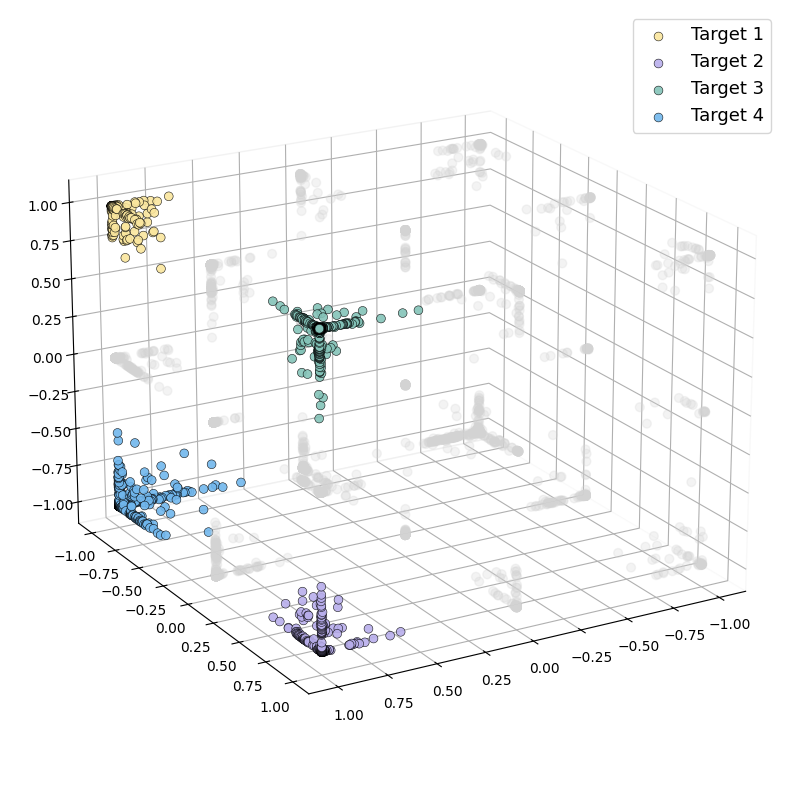

In [ ]:
validdata20 = pd.read_csv('./validdata20.csv')
validdata30 = pd.read_csv('./validdata30.csv')
validdataread = pd.read_csv('./validdataread.csv')
validdatarw1 = pd.read_csv('./数据校验/validdatarw1.csv')
validdata613 = pd.read_csv('./数据校验/validdata613.csv')
step_20 = pd.read_csv('./step_20.csv')
step_30 = pd.read_csv('./step_30.csv')
step_read = pd.read_csv('./step_read.csv')
step_613 = pd.read_csv('./step_613.csv')
labelbin = np.arange(0,2.5,0.5) / 44 * 20000
labelbin.round(0) # 227,455
def modify_valuer1(x):
    #高导
    if x==0 or x==1:
        return 1
    # 低导
    elif x==2 or x==3 :
        return -1
    elif x==6:
        return 0.9
    elif x==7:
        return -0.9
    # 高-低
    else:
        return 0

datacluster['rr0'] = datacluster['labelR0']
datacluster['rr1'] = datacluster['labelR1']
datacluster['rr2'] = datacluster['labelR2']
datacluster['rr0'] = datacluster['rr0'].apply(modify_valuer1)
datacluster['rr1'] = datacluster['rr1'].apply(modify_valuer1)
datacluster['rr2'] = datacluster['rr2'].apply(modify_valuer1)
datacluster['rr0'] = datacluster['rr0']*datacluster['prob0']
datacluster['rr1'] = datacluster['rr1']*datacluster['prob1']
datacluster['rr2'] = datacluster['rr2']*datacluster['prob2']
xxX = datacluster[['rr0','rr1','rr2']].values
# 定义目标类和马卡龙色系
target_classes = [53, 59, 14, 18]
target_labels = {53: "Target 1", 59: "Target 2", 14: "Target 3", 18: "Target 4"}
target_colors = {
    53: "#fae69ea6",  
    59: "#b8aeeb97",  
    14: "#84c3b88a",  
    18: "#71b7ed85"   
}

# 所有类
all_classes = np.unique(datacluster['cc'])
other_classes = [c for c in all_classes if c not in target_classes]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

# 绘制目标类 (马卡龙色)
for cluster_id in target_classes:
    mask = datacluster['cc'] == cluster_id
    ax.scatter(
        xxX[mask,0], xxX[mask,1], xxX[mask,2],
        c=target_colors[cluster_id],
        label=target_labels[cluster_id],   # 修改标签
        s=40, alpha=0.9, edgecolors="k", linewidths=0.4
    )

# 绘制非目标类 (统一淡灰色，降低存在感)
for cluster_id in other_classes:
    mask = datacluster['cc'] == cluster_id
    ax.scatter(
        xxX[mask,0], xxX[mask,1], xxX[mask,2],
        c="lightgray", s=40, alpha=0.25
    )
ax.set_facecolor("white") 
ax.xaxis.pane.set_facecolor("w")
ax.yaxis.pane.set_facecolor("w")
ax.zaxis.pane.set_facecolor("w")
ax.view_init(elev=20, azim=60
             )
plt.tight_layout()
ax.legend(fontsize=13, loc="upper right", frameon=True, markerscale=1)
# plt.savefig('./cluster2.png',dpi=300)
plt.show()
plt.close()

In [ ]:
numhlh = datacluster[datacluster['mostcluster']==300]['num'].values
numhhl = datacluster[datacluster['mostcluster']==301]['num'].values
numhhh = datacluster[datacluster['mostcluster']==14]['num'].values
numhll = datacluster[datacluster['mostcluster']==18]['num'].values
numhlhhu = datacluster[datacluster['mostcluster']==53]['num'].values
numhhlhu = datacluster[datacluster['mostcluster']==59]['num'].values
datahlh = []
datahhl = []
datahhh = []
datahll = []

datahlh0_05 = []
datahhl0_05 = []
datahhh0_05 = []
datahll0_05 = []
xulie0_05 = []

datahlh05_10 = []
datahhl05_10 = []
datahhh05_10 = []
datahll05_10 = []
xulie05_10 = []

datahlh10_15 = []
datahhl10_15 = []
datahhh10_15 = []
datahll10_15 = []
xulie10_15 = []

datahlh15_20 = []
datahhl15_20 = []
datahhh15_20 = []
datahll15_20 = []
xulie15_20 = []

xulie = []
validhlhnum = 0
validhhlnum = 0
hlhnum =0
hhlnum = 0
hhhnum = 0
hllnum=0
minbias = -1.5
maxbias = 1.5
step_hhl = pd.DataFrame()
step_hlh = pd.DataFrame()
step_hhh = pd.DataFrame()
step_hll = pd.DataFrame()
valid_step = pd.DataFrame()
for groupnum,data in validdata20.groupby('Number'):
    if groupnum in numhlh or groupnum in numhhl or groupnum in numhhh or groupnum in numhll or groupnum in numhlhhu or groupnum in numhhlhu:
        bias = data['Bias (V)'].values.round(1)
        conduct = data['Log(G/G0)'].values
        prev_bias = bias[:-1]
        next_bias = bias[1:]
        idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] + 1
        if len(idx_n1_01)>0: 
            R2 = data[idx_n1_01[0]+200:-50]   
            data_len = len(R2)
            # print(data_len)
            if(data_len>1500):
                slope2 = get_slope(R2['Log(G/G0)'][100:800].dropna())
                if slope2[0]>-0.0003:
                    if groupnum in numhlh:
                        xulie.append(1)
                        validhlhnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahlh.append(list)
                        step_value = step_20.loc[step_20['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahlh0_05.append(list)
                            xulie0_05.append(1)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahlh05_10.append(list)
                            xulie05_10.append(1)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahlh10_15.append(list)
                            xulie10_15.append(1)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahlh15_20.append(list)
                            xulie15_20.append(1)
                        step_hlh = pd.concat([step_hlh, pd.DataFrame({'Group': [groupnum], 'conduct': [step_value]})], ignore_index=True)
                    elif groupnum in numhhl:
                        xulie.append(2)
                        validhhlnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()   
                        step_value = step_20.loc[step_20['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahhl0_05.append(list)
                            xulie0_05.append(2)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahhl05_10.append(list)
                            xulie05_10.append(2)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahhl10_15.append(list)
                            xulie10_15.append(2)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahhl15_20.append(list)
                            xulie15_20.append(2)
                        step_hhl = pd.concat([step_hhl, pd.DataFrame({'Group': [groupnum], 'conduct': [step_value]})], ignore_index=True)     
                        datahhl.append(list)
                    elif groupnum in numhlhhu:
                        hlhnum += 1
                    elif groupnum in numhhlhu:
                        hhlnum += 1
                    elif groupnum in numhhh:
                        xulie.append(3)
                        hhhnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahhh.append(list)
                        step_value = step_20.loc[step_20['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahhh0_05.append(list)
                            xulie0_05.append(3)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahhh05_10.append(list)
                            xulie05_10.append(3)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahhh10_15.append(list)
                            xulie10_15.append(3)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahhh15_20.append(list)
                            xulie15_20.append(3)
                        step_hhh = pd.concat([step_hhh, pd.DataFrame({'Group': [groupnum], 'conduct': [step_value]})], ignore_index=True)
                    else:
                        hllnum += 1
                        xulie.append(4)
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahll.append(list)
                        step_value = step_20.loc[step_20['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahll0_05.append(list)
                            xulie0_05.append(4)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahll05_10.append(list)
                            xulie05_10.append(4)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahll10_15.append(list)
                            xulie10_15.append(4)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahll15_20.append(list)
                            xulie15_20.append(4)
                        step_hll = pd.concat([step_hll, pd.DataFrame({'Group': [groupnum], 'conduct': [step_value]})], ignore_index=True)
                    step_value = step_20.loc[step_20['Group'] == groupnum, 'conduct'].values[-1]
                    valid_step = pd.concat([valid_step, pd.DataFrame({'Group': [groupnum], 'conduct': [step_value]})], ignore_index=True)
for groupnum,data in validdata30.groupby('Number'):
    if groupnum in numhlh-2500 or groupnum in numhhl-2500 or groupnum in numhhh-2500 or groupnum in numhll-2500 or groupnum in numhlhhu-2500 or groupnum in numhhlhu-2500:
        bias = data['Bias (V)'].values.round(1)
        conduct = data['Log(G/G0)'].values
        prev_bias = bias[:-1]
        next_bias = bias[1:]
        idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] + 1
        if len(idx_n1_01)>0: 
            R2 = data[idx_n1_01[0]+200:-50]   
            data_len = len(R2)
            # print(data_len)
            if(data_len>1500):
                slope2 = get_slope(R2['Log(G/G0)'][100:800].dropna())
                if slope2[0]>-0.0003:
                    if groupnum in numhlh-2500:
                        xulie.append(1)
                        validhlhnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahlh.append(list)
                        step_value = step_30.loc[step_30['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahlh0_05.append(list)
                            xulie0_05.append(1)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahlh05_10.append(list)
                            xulie05_10.append(1)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahlh10_15.append(list)
                            xulie10_15.append(1)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahlh15_20.append(list)
                            xulie15_20.append(1)
                        step_hlh = pd.concat([step_hlh, pd.DataFrame({'Group': [groupnum+2500], 'conduct': [step_value]})], ignore_index=True)
                    elif groupnum in numhhl-2500:
                        xulie.append(2)
                        validhhlnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahhl.append(list)
                        step_value = step_30.loc[step_30['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahhl0_05.append(list)
                            xulie0_05.append(2)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahhl05_10.append(list)
                            xulie05_10.append(2)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahhl10_15.append(list)
                            xulie10_15.append(2)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahhl15_20.append(list)
                            xulie15_20.append(2)
                        step_hhl = pd.concat([step_hhl, pd.DataFrame({'Group': [groupnum+2500], 'conduct': [step_value]})], ignore_index=True)
                    elif groupnum in numhlhhu-2500:
                        hlhnum += 1
                    elif groupnum in numhhlhu-2500:
                        hhlnum += 1
                    elif groupnum in numhhh-2500:
                        xulie.append(3)
                        hhhnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahhh.append(list)
                        step_value = step_30.loc[step_30['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahhh0_05.append(list)
                            xulie0_05.append(3)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahhh05_10.append(list)
                            xulie05_10.append(3)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahhh10_15.append(list)
                            xulie10_15.append(3)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahhh15_20.append(list)
                            xulie15_20.append(3)
                        step_hhh = pd.concat([step_hhh, pd.DataFrame({'Group': [groupnum+2500], 'conduct': [step_value]})], ignore_index=True)
                    else:
                        xulie.append(4)
                        hllnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahll.append(list)
                        step_value = step_30.loc[step_30['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahll0_05.append(list)
                            xulie0_05.append(4)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahll05_10.append(list)
                            xulie05_10.append(4)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahll10_15.append(list)
                            xulie10_15.append(4)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahll15_20.append(list)
                            xulie15_20.append(4)
                        step_hll = pd.concat([step_hll, pd.DataFrame({'Group': [groupnum+2500], 'conduct': [step_value]})], ignore_index=True)
                    step_value = step_30.loc[step_30['Group'] == groupnum, 'conduct'].values[-1]
                    valid_step = pd.concat([valid_step, pd.DataFrame({'Group': [groupnum+2500], 'conduct': [step_value]})], ignore_index=True)
for groupnum,data in validdataread.groupby('Number'):
    if groupnum in numhlh-4000 or groupnum in numhhl-4000 or groupnum in numhhh-4000 or groupnum in numhll-4000 or groupnum in numhlhhu-4000 or groupnum in numhhlhu-4000:
        bias = data['Bias (V)'].values.round(1)
        conduct = data['Log(G/G0)'].values
        prev_bias = bias[:-1]
        next_bias = bias[1:]
        idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] + 1
        if  len(idx_n1_01)>0: 
            R2 = data[idx_n1_01[0]+200:-50]   
            data_len = len(R2)
            # print(data_len)
            if(data_len>1500):
                slope2 = get_slope(R2['Log(G/G0)'][100:800].dropna())
                if slope2[0]>-0.0003:
                    if groupnum in numhlh-4000:
                        xulie.append(1)
                        validhlhnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahlh.append(list)
                        step_value = step_read.loc[step_read['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahlh0_05.append(list)
                            xulie0_05.append(1)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahlh05_10.append(list)
                            xulie05_10.append(1)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahlh10_15.append(list)
                            xulie10_15.append(1)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahlh15_20.append(list)
                            xulie15_20.append(1)
                        step_hlh = pd.concat([step_hlh, pd.DataFrame({'Group': [groupnum+4000], 'conduct': [step_value]})], ignore_index=True)
                    elif groupnum in numhhl-4000:
                        xulie.append(2)
                        validhhlnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahhl.append(list)
                        step_value = step_read.loc[step_read['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahhl0_05.append(list)
                            xulie0_05.append(2)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahhl05_10.append(list)
                            xulie05_10.append(2)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahhl10_15.append(list)
                            xulie10_15.append(2)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahhl15_20.append(list)
                            xulie15_20.append(2)
                        step_hhl = pd.concat([step_hhl, pd.DataFrame({'Group': [groupnum+4000], 'conduct': [step_value]})], ignore_index=True)
                    elif groupnum in numhlhhu-4000:
                        hlhnum += 1
                    elif groupnum in numhhlhu-4000:
                        hhlnum += 1
                    elif groupnum in numhhh-4000:
                        xulie.append(3)
                        hhhnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahhh.append(list)
                        step_value = step_read.loc[step_read['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahhh0_05.append(list)
                            xulie0_05.append(3)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahhh05_10.append(list)
                            xulie05_10.append(3)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahhh10_15.append(list)
                            xulie10_15.append(3)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahhh15_20.append(list)
                            xulie15_20.append(3)
                        step_hhh = pd.concat([step_hhh, pd.DataFrame({'Group': [groupnum+4000], 'conduct': [step_value]})], ignore_index=True)
                    else:
                        xulie.append(4)
                        hllnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahll.append(list)
                        step_value = step_read.loc[step_read['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahll0_05.append(list)
                            xulie0_05.append(4)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahll05_10.append(list)
                            xulie05_10.append(4)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahll10_15.append(list)
                            xulie10_15.append(4)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahll15_20.append(list)
                            xulie15_20.append(4)
                        step_hll = pd.concat([step_hll, pd.DataFrame({'Group': [groupnum+4000], 'conduct': [step_value]})], ignore_index=True)
                    step_value = step_read.loc[step_read['Group'] == groupnum, 'conduct'].values[-1]
                    valid_step = pd.concat([valid_step, pd.DataFrame({'Group': [groupnum+4000], 'conduct': [step_value]})], ignore_index=True)
for groupnum,data in validdata613.groupby('Number'):
    if groupnum in numhlh-10000 or groupnum in numhhl-10000 or groupnum in numhhh-10000 or groupnum in numhll-10000 or groupnum in numhlhhu-10000 or groupnum in numhhlhu-10000:
        bias = data['Bias (V)'].values.round(1)
        conduct = data['Log(G/G0)'].values
        prev_bias = bias[:-1]
        next_bias = bias[1:]
        idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] + 1
        if  len(idx_n1_01)>0: 
            R2 = data[idx_n1_01[0]+200:-50]   
            data_len = len(R2)
            # print(data_len)
            if(data_len>1500):
                slope2 = get_slope(R2['Log(G/G0)'][100:800].dropna())
                if slope2[0]>-0.0003:
                    if groupnum in numhlh-10000:
                        xulie.append(1)
                        validhlhnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahlh.append(list)
                        step_value = step_613.loc[step_613['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahlh0_05.append(list)
                            xulie0_05.append(1)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahlh05_10.append(list)
                            xulie05_10.append(1)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahlh10_15.append(list)
                            xulie10_15.append(1)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahlh15_20.append(list)
                            xulie15_20.append(1)
                        step_hlh = pd.concat([step_hlh, pd.DataFrame({'Group': [groupnum+10000], 'conduct': [step_value]})], ignore_index=True)
                    elif groupnum in numhhl-10000:
                        xulie.append(2)
                        validhhlnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahhl.append(list)
                        step_value = step_613.loc[step_613['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahhl0_05.append(list)
                            xulie0_05.append(2)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahhl05_10.append(list)
                            xulie05_10.append(2)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahhl10_15.append(list)
                            xulie10_15.append(2)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahhl15_20.append(list)
                            xulie15_20.append(2)
                        step_hhl = pd.concat([step_hhl, pd.DataFrame({'Group': [groupnum+10000], 'conduct': [step_value]})], ignore_index=True)
                    elif groupnum in numhlhhu-10000:
                        hlhnum += 1
                    elif groupnum in numhhlhu-10000:
                        hhlnum += 1
                    elif groupnum in numhhh-10000:
                        xulie.append(3)
                        hhhnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahhh.append(list)
                        step_value = step_613.loc[step_613['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahhh0_05.append(list)
                            xulie0_05.append(3)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahhh05_10.append(list)
                            xulie05_10.append(3)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahhh10_15.append(list)
                            xulie10_15.append(3)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahhh15_20.append(list)
                            xulie15_20.append(3)
                        step_hhh = pd.concat([step_hhh, pd.DataFrame({'Group': [groupnum+10000], 'conduct': [step_value]})], ignore_index=True)
                    else:
                        xulie.append(4)
                        hllnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahll.append(list)
                        step_value = step_613.loc[step_613['Group'] == groupnum, 'conduct'].values[-1]
                        if step_value > 0 and step_value < labelbin[1]:
                            datahll0_05.append(list)
                            xulie0_05.append(4)
                        elif step_value >= labelbin[1] and step_value < labelbin[2]:
                            datahll05_10.append(list)
                            xulie05_10.append(4)
                        elif step_value >= labelbin[2] and step_value < labelbin[3]:
                            datahll10_15.append(list)
                            xulie10_15.append(4)
                        elif step_value >= labelbin[3] and step_value < labelbin[4]:
                            datahll15_20.append(list)
                            xulie15_20.append(4)
                        step_hll = pd.concat([step_hll, pd.DataFrame({'Group': [groupnum+10000], 'conduct': [step_value]})], ignore_index=True)
                    step_value = step_613.loc[step_613['Group'] == groupnum, 'conduct'].values[-1]
                    valid_step = pd.concat([valid_step, pd.DataFrame({'Group': [groupnum+10000], 'conduct': [step_value]})], ignore_index=True)
for groupnum,data in validdatarw1.groupby('Number'):
    if groupnum in numhlh-14000 or groupnum in numhhl-14000 or groupnum in numhhh-14000 or groupnum in numhll-14000 or groupnum in numhlhhu-14000 or groupnum in numhhlhu-14000:
        bias = data['Bias (V)'].values.round(1)
        conduct = data['Log(G/G0)'].values
        prev_bias = bias[:-1]
        next_bias = bias[1:]
        idx_1_01 = np.where((prev_bias == maxbias) & (next_bias == 0.1))[0] + 1
        idx_01_n1 = np.where((prev_bias == 0.1) & (next_bias == minbias))[0] + 1
        # R2的开始索引
        idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] + 1

        # 计算电导长度
        idx_01_10 = np.where((prev_bias == 0.1) & (next_bias == maxbias))[0]
        if len(idx_1_01)>0 and len(idx_01_n1)>0 and len(idx_n1_01)>0: 
            R0 = data[2200:idx_01_10[0]]
            R1 = data[idx_1_01[0]+200:idx_01_n1[0]-50]
            R2 = data[idx_n1_01[0]+200:-50] 
            data_len = min(len(R0),  len(R1),  len(R2))  
            Cr0 = R0['Log(G/G0)'].values[-data_len:].round(1)
            Cr1 = R1['Log(G/G0)'].values[-data_len:].round(1)
            Cr2 = R2['Log(G/G0)'].values[-data_len:].round(1)
            mean0 = np.mean(Cr0)
            mean1 = np.mean(Cr1)
            mean2 = np.mean(Cr2)
            mean01 = mean0 - mean1
            mean02 = mean0 - mean2
            mean12 = mean1 - mean2
            if(data_len>1500): 
                slope2 = get_slope(R2['Log(G/G0)'][100:800].dropna())
                if slope2[0]>-0.0003:
                    if groupnum in numhlh-14000:
                        if mean01 > 0.2 and mean12 < -0.2:
                            xulie.append(1)
                            validhlhnum += 1
                            data = data[2000:]
                            data['x'] = np.linspace(0,500,len(data))
                            list = data[['x','Log(G/G0)']].values.tolist()        
                            datahlh.append(list)
                    elif groupnum in numhhl-14000:
                        xulie.append(2)
                        validhhlnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahhl.append(list)
                    elif groupnum in numhlhhu-14000:
                        hlhnum += 1
                    elif groupnum in numhhlhu-14000:
                        hhlnum += 1
                    elif groupnum in numhhh-14000:
                        xulie.append(3)
                        hhhnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahhh.append(list)
                    else:
                        xulie.append(4)
                        hllnum += 1
                        data = data[2000:]
                        data['x'] = np.linspace(0,500,len(data))
                        list = data[['x','Log(G/G0)']].values.tolist()        
                        datahll.append(list)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11244\3666569742.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['x'] = np.linspace(0,500,len(data))
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11244\3666569742.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['x'] = np.linspace(0,500,len(data))
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11244\3666569742.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [ ]:
print(f"validhhl:{validhhlnum},validhlhnum:{validhlhnum},hhhnum:{hhhnum},hllnum:{hllnum},totol:{validhhlnum+validhlhnum+hhhnum+hllnum}")

validhhl:156,validhlhnum:70,hhhnum:1489,hllnum:564,totol:2279


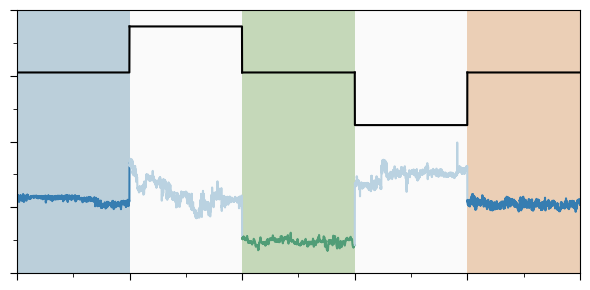

In [ ]:
def smooth_segment(df, window=10):
    """对单段数据做平滑，每 window 个点取平均"""
    n = len(df) // window
    if n == 0:
        return df  # 太短不处理
    df = df.iloc[:n*window]  # 保证整除
    smoothed = df.groupby(df.index // window).mean()
def plot_bias_log(group_data,style):
    # 提取 bias 和 log 数据
    bias = group_data['Bias (V)'].values.round(1)
    prev_bias = bias[:-1]
    next_bias = bias[1:]
    maxbias = 1.5
    minbias = -1.5
    # R1的起始索引
    idx_1_01 = np.where((prev_bias == maxbias) & (next_bias == 0.1))[0] 
    idx_01_n1 = np.where((prev_bias == 0.1) & (next_bias == minbias))[0] 
    # R2的开始索引
    idx_n1_01 = np.where((prev_bias == minbias) & (next_bias == 0.1))[0] 

    # 计算电导长度
    idx_01_10 = np.where((prev_bias == 0.1) & (next_bias == maxbias))[0]
    # 截取忆阻判断的两段   
    # print(idx_1_01,idx_01_n1)  
    if len(idx_1_01)>0 and len(idx_01_n1)>0 and len(idx_n1_01)>0:                                                                                                                     
        R0 = group_data[2100:idx_01_10[0]-50]
        Rmax = group_data[idx_01_10[0]+100:idx_1_01[0]-50]                                                                                                                 
        R1 = group_data[idx_1_01[0]+100:idx_01_n1[0]-50]
        Rmin =group_data[idx_01_n1[0]+100:idx_n1_01[0]-50]
        R2 = group_data[idx_n1_01[0]+100:-1] 
        min_len = min(len(R0),len(R1),len(R2),len(Rmin),len(Rmax)) 
        R0 = R0.iloc[:min_len]
        Rmax = Rmax.iloc[:min_len]
        R1 = R1.iloc[:min_len]
        Rmin = Rmin.iloc[:min_len]
        R2 = R2.iloc[:min_len]
        R0 = pd.concat([R0,Rmax.iloc[0:2]], ignore_index=True)  # R0 末尾添加 Rmax 的第一行
        Rmax = pd.concat([Rmax,R1.iloc[0:2]], ignore_index=True)  # Rmax 末尾添加最后一行
        R1 = pd.concat([R1,R1.iloc[-2:]], ignore_index=True)  # R1 末尾添加 Rmax 的最后一行
        Rmin = pd.concat([R1.iloc[[-1]],Rmin,R2.iloc[[0]]], ignore_index=True)  # Rmin 的末尾添加 Rmax 的最后一行
        R2 = pd.concat([R2,R2.iloc[-2:]], ignore_index=True)
    segments = {'R0': R0, 'RMAX': Rmax, 'R1': R1, 'RMIN': Rmin, 'R2': R2}
    # for key in segments.keys():
    #     segments[key] = smooth_segment(segments[key], window=10)
    # 找到最小长度
    min_len = min(len(seg) for seg in segments.values())
    colors = {}
    # 设置颜色
    if style == 'hhl':
        colors = {
            'R0':"#0F5694",
            'RMAX': '#BAD2E1',
            'R1': '#0F5694',
            'RMIN': '#BAD2E1',
            'R2': "#437433"
        }
    elif style == 'hlh':
        colors = {
            'R0':'#367db1',
            'RMAX': '#BAD2E1',
            'R1': '#519d77',
            'RMIN': '#BAD2E1',
            'R2': '#367db1'
        }
    elif style == 'hll':
        colors = {
            'R0':'#0F5694',
            'RMAX': '#BAD2E1',
            'R1': '#437433',
            'RMIN': '#BAD2E1',
            'R2': '#437433'
        }
    elif style == 'lhl':
        colors = {
            'R0':'#437433',
            'RMAX': '#BAD2E1',
            'R1': '#0F5694',
            'RMIN': '#BAD2E1',
            'R2': '#437433'
        }
    elif style == 'lhh':
        colors = {
            'R0':'#437433',
            'RMAX': '#BAD2E1',
            'R1': '#0F5694',
            'RMIN': '#BAD2E1',
            'R2': '#0F5694'
        }
    elif style == 'llh':
        colors = {
            'R0':'#437433',
            'RMAX': '#BAD2E1',
            'R1': '#437433',
            'RMIN': '#BAD2E1',
            'R2': '#0F5694'
        }
    elif style == 'hhh':
        colors = {
            'R0':'#0F5694',
            'RMAX': '#BAD2E1',
            'R1': '#0F5694',
            'RMIN': '#BAD2E1',
            'R2': '#0F5694'
        }
    elif style == 'lll':
        colors = {
            'R0':'#437433',
            'RMAX': '#BAD2E1',
            'R1': '#437433',
            'RMIN': '#BAD2E1',
            'R2': '#437433'
        }

    
    total_points = min_len * 5
    scale_factor = 500 / total_points  # 缩放 x 轴为 0~500
    # 创建图像
    fig, ax = plt.subplots(figsize=(6,3))
    # ax.set_xlim(0, min_len * 5)
    # ax.axhline(y=-4.5, color='black')  # y=-2 的黑色实线

    x_offset = 0
    # colors_bg = ["#b6f1f9","#f0f0f0", "#9DFECD", "#f0f0f0", "#b6f1f9"]  # 循环用的颜色
    # colors_bg = ["#8683d6ff","#f0f0f0", "#f5af87ff", "#f0f0f0", "#fdeb71ff"]  # 循环用的颜色
    colors_bg = ["#206087","#f0f0f0", "#427F19", "#f0f0f0", "#be600e"]  # 循环用的颜色
    # colors_bg = ["#ffb617","#f0f0f0", "#e45a1a", "#f0f0f0", "#fddc07ff"]  # 循环用的颜色
    # colors_bg = ["#d9e8fa","#f0f0f0", "#e3d4e7d2", "#f0f0f0", "#fff3ced6"]  # 循环用的颜色
    for i in range(5):  # 因为 x 总长 500
        ax.axvspan(i*100, (i+1)*100, facecolor=colors_bg[i % len(colors_bg)], alpha=0.3)
    prev_last_point = None
    keys = ['R0', 'RMAX', 'R1', 'RMIN', 'R2']
    for i,name in enumerate(['R0', 'RMAX', 'R1', 'RMIN', 'R2']): 
        df = segments[name].iloc[:min_len]
        y = df['Log(G/G0)'].values
        if i!=4 :
            df1 = segments[keys[i+1]].iloc[:min_len] 
            y1 = df1['Log(G/G0)'].values
            if df1.iloc[0]['Bias (V)'] == -1.34:
                df1.iloc[0]['Bias (V)'] = -1.5
            df.iloc[-1] = df1.iloc[0] 
            # print(df.iloc[-1])
            # df.iloc[-1] = df1.iloc[1]
        x_raw = np.arange(min_len) + x_offset 
        x = x_raw * scale_factor 
        color = colors.get(name, 'gray')
        ax.plot(x, df['Log(G/G0)'].values, color=color, label=f'{name} log') # ax.plot(x, df['Bias (V)'].values, color='black', label=f'{name} bias')

        ax.plot(x, df['Bias (V)'].values, color='black', label=f'{name} bias')
        
        # 标签
        # if name == 'R0':
        #     ax.text(x[min_len // 2], df['Bias (V)'].values[min_len // 2] + 0.12, r'R$\regular{_0}$', ha='center', color='black',fontdict={'fontsize': 9, 'fontweight': 'bold'})
        # if name == 'RMAX':
        #     ax.text(x[min_len // 2], df['Bias (V)'].values[min_len // 2] + 0.12, 'W', ha='center', color='black',fontdict={'fontsize': 9, 'fontweight': 'bold'})
        # elif name == 'R1':
        #     ax.text(x[min_len // 2], df['Bias (V)'].values[min_len // 2] + 0.12, r'R$\regular{_1}$', ha='center', color='black',fontdict={'fontsize': 9, 'fontweight': 'bold'})
        # elif name == 'RMIN':
        #     ax.text(x[min_len // 2], df['Bias (V)'].values[min_len // 2] + 0.12, 'E', ha='center', color='black',fontdict={'fontsize': 9, 'fontweight': 'bold'})
        # elif name == 'R2':
        #     ax.text(x[min_len // 2], df['Bias (V)'].values[min_len // 2] + 0.12, r'R$\regular{_2}$', ha='center', color='black',fontdict={'fontsize': 9, 'fontweight': 'bold'})
        prev_last_point = df.iloc[[-1]]
        # x_offset += len(df) -1
        x_offset += min_len

    # 坐标轴设置
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_xlabel('Time (ms)',fontdict={'fontsize': 10, 'fontweight': 'bold'},labelpad=5)
    # ax.set_ylabel(r'Log ($\regular{G/G_0}$)           $\regular{V _{bias}}$ (V)',fontdict={'fontsize': 10, 'fontweight': 'bold'})
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)   
    # ax.spines['bottom'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    ax.set_xlim(0, 500)
    ax.set_ylim(-6, 2)
    ax.minorticks_on()
    ax.tick_params(axis='both',which='minor',length=3)  
    ax.tick_params(axis='both',which='major',length=5)
    ax.xaxis.set_minor_locator(MultipleLocator(50))
    ax.yaxis.set_major_locator(MultipleLocator(2))
    ax.yaxis.set_minor_locator(MultipleLocator(1))
    # plt.xticks([])
    # plt.yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    # plt.xticks(fontsize=10)
    # plt.yticks(fontsize=10)
    # plt.xticks(fontsize=8,fontweight='bold')
    # plt.yticks(fontsize=8,fontweight='bold')
    plt.tight_layout()
    plt.savefig('./data0307_无坐标.png',transparent=True,dpi=300)
    plt.show()
    # plt.close()
for num,data in validdata20.groupby('Number'):
    if num == 1083:
        plot_bias_log(data,'hlh') 

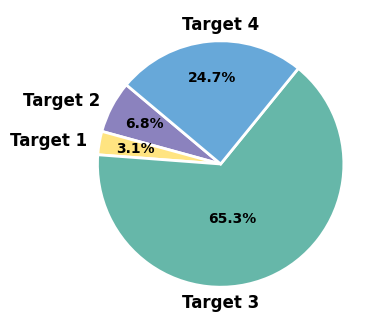

In [ ]:
import matplotlib.pyplot as plt
 
sizes = [156, 70, 1489, 564]
labels = ["Target 2", "Target 1", "Target 3", "Target 4"]
colors = ["#8b82beff", "#ffe481ff", "#66b7a9ff", "#67a8d9ff"]  
total = sum(sizes)


# 计算百分比
percents = [s/total*100 for s in sizes]

fig, ax = plt.subplots(figsize=(4,4))

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",  # 小于3%的不显示
    startangle=140, pctdistance=0.7,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)

# 文字优化
plt.setp(autotexts, size=10, weight="bold", color="black")
plt.setp(texts, size=12,weight='bold')
import numpy as np
try:
    idx = 2  # 第三块
    x, y = autotexts[idx].get_position()
    r = np.hypot(x, y)
    theta = np.arctan2(y, x)
    new_r = r * 0.7  # 比例可调，越小越靠中心
    new_x = new_r * np.cos(theta) *0.5
    new_y = new_r * np.sin(theta)
    autotexts[idx].set_position((new_x, new_y))
except Exception:
    pass
try:
    # 要移动的标签名（按需修改）
    top_label_name = "Target 4"   # 移到正上方中心
    bottom_label_name = "Target 3" # 移到正下方中心

    # 隐藏原有对应标签（如果存在）
    for t in texts:
        if t.get_text() in (top_label_name, bottom_label_name):
            t.set_visible(False)

    # 在 axes 的相对坐标系（0-1）上添加新标签：x=0.5 居中，y 接近上/下边缘
    ax.text(0.5, 0.98, top_label_name, transform=ax.transAxes,
            ha='center', va='top', fontsize=12, fontweight='bold')

    ax.text(0.5, 0.02, bottom_label_name, transform=ax.transAxes,
            ha='center', va='bottom', fontsize=12, fontweight='bold')
except Exception:
    pass

# plt.savefig('./bingtunew.png',dpi=300)
plt.show()
plt.close()

In [ ]:
datahhl = pd.DataFrame(np.vstack(datahhl),columns=['x','log'])
datahhl = datahhl.dropna()
datahlh = pd.DataFrame(np.vstack(datahlh),columns=['x','log'])
datahlh = datahlh.dropna()
datahhh = pd.DataFrame(np.vstack(datahhh),columns=['x','log'])
datahhh = datahhh.dropna()
datahll = pd.DataFrame(np.vstack(datahll),columns=['x','log'])
datahll = datahll.dropna()

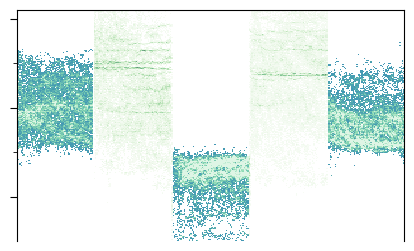

In [ ]:
fig, ax = plt.subplots(figsize=(5,3))
import matplotlib.colors as mcolors
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    "blue_red", ["#3486bc","#4ba2b0d9","#8ad9b2da","#def5e5"]
)
intervals = [(0,98), (99,201), (201,299), (299,401), (402,500)]
for i, (start, end) in enumerate(intervals):
    mask = (datahlh['x'] >= start) & (datahlh['x'] < end)
    x_seg = datahlh.loc[mask, 'x']
    y_seg = datahlh.loc[mask, 'log']
    xrange = (start,end)
    yrange = (-6, -2.9)
    # 控制颜色映射和透明度
    if (start, end) in [(99,201), (299,401)]:
        # 淡一些
        h = ax.hist2d(x_seg, y_seg, vmin=0,cmin=2
                      ,

                      bins=[60,800], cmap="Greens",range=[xrange,yrange], alpha=0.6)
    else:
        # 正常显示
        h = ax.hist2d(x_seg, y_seg, vmin=0, vmax=25,cmin=5,
                      bins=[60,600], cmap=cmap_custom, range=[xrange,yrange],alpha=1.0)

# 公共设置
ax.set_ylim(-5.5, -2.9)
ax.set_xlim(0,500)
# ax.set_xlabel("Time (ms)",fontdict={'fontsize': 13, 'fontweight': 'bold'},labelpad=4)
# ax.set_ylabel(r"Log (G/G$\regular{_0}$)",fontdict={'fontsize': 13, 'fontweight': 'bold'},labelpad=4)
ax.minorticks_on()
ax.tick_params(axis='both',which='minor',length=3)
ax.tick_params(axis='both',which='major',length=5)
# ax.xaxis.set_minor_locator(MultipleLocator(50))
# ax.yaxis.set_minor_locator(MultipleLocator(0.25))
# plt.xticks(fontsize=12,fontweight='bold')
# plt.yticks(fontsize=12,fontweight='bold')
# ax.grid(True, which='both', linestyle='--', alpha=0.3)
# plt.xticks([])
# plt.yticks([])
ax.set_yticks([-5,-4,-3])
ax.set_yticks([-4.5,-3.5], minor=True)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xticks([])
ax.set_yticklabels([])
ax.spines['bottom'].set_visible(False)
# 统一 colorbar（来自最后一次 hist2d 的结果）
# cax = fig.add_axes([ax.get_position().x0+0.02,ax.get_position().y0+0.02,0.03,ax.get_position().height*0.2])
# colorbar = plt.colorbar(h [3], cax=cax,ticks=[0, 25, 50])
# 修改刻度字体大小
# colorbar.ax.tick_params(labelsize=8)
# for tl in colorbar.ax.get_yticklabels():   # 若是水平 colorbar 用 get_xticklabels()
#     tl.set_fontweight('bold')
# 加粗 colorbar 外框线
plt.savefig('./hlh0307_无坐标.png',transparent=True,dpi=300)
# plt.savefig('./hlh0307_有刻度.png',dpi=300)

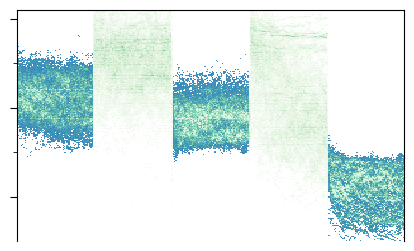

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap
# 原先定义的 cmap_custom 保持或自定义
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    "blue_red", ["#fff","#3486bc","#4ba2b0d9","#8ad9b2da","#def5e5"]
)

# 设置颜色映射的数值范围和阈值
vmin = 0.0
vmax = 50.0   # 与 hist2d 中的 vmax 对应
threshold = 10.0  # 0-10 映射为白色

# 基于原 colormap 采样并把 0~threshold 区间全部设为白色
ncolors = 256
base_colors = cmap_custom(np.linspace(0, 1, ncolors))
# 计算阈值对应的索引并置白
th_idx = int((threshold - vmin) / (vmax - vmin) * (ncolors - 1))
th_idx = max(0, min(ncolors-1, th_idx))
base_colors[:th_idx+1, :] = np.array([1.0, 1.0, 1.0, 1.0])  # RGBA 白色

new_cmap = ListedColormap(base_colors)
# fig, ax = plt.subplots(figsize=(7,4))
fig, ax = plt.subplots(figsize=(5,3))
intervals = [(0,98), (98,201), (201,299), (299,402), (402,500)]
for i, (start, end) in enumerate(intervals):
    mask = (datahhl['x'] >= start) & (datahhl['x'] < end)
    x_seg = datahhl.loc[mask, 'x']
    y_seg = datahhl.loc[mask, 'log']
    xrange = (start,end)
    yrange = (-6, -2.9)
    # 控制颜色映射和透明度
    if (start, end) in [(98,201), (299,402)]:
        # 淡一些
        h = ax.hist2d(x_seg, y_seg, vmin=0,cmin=5
                      ,
                      bins=[60,800], cmap="Greens",range=[xrange,yrange], alpha=0.4)
    else:
        # 正常显示
        h = ax.hist2d(x_seg, y_seg, vmin=0,vmax=50,cmin=10,
                      bins=[60,620], cmap=new_cmap, range=[xrange,yrange],alpha=1.0)

# 公共设置
ax.set_ylim(-5.5, -2.9)
ax.set_xlim(0,500)
# ax.set_xlabel("Time (ms)",fontdict={'fontsize': 13, 'fontweight': 'bold'},labelpad=4)
# ax.set_ylabel(r"Log (G/G$\regular{_0}$)",fontdict={'fontsize': 13, 'fontweight': 'bold'},labelpad=4)
ax.minorticks_on()
ax.tick_params(axis='both',which='minor',length=3)
ax.tick_params(axis='both',which='major',length=5)
# ax.xaxis.set_minor_locator(MultipleLocator(50))
# ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.25))
# plt.xticks([])
# plt.yticks([])
ax.set_xticks([])
ax.set_yticklabels([])
ax.set_yticks([-5,-4,-3])
ax.set_yticks([-4.5,-3.5], minor=True)
ax.spines['bottom'].set_visible(False)
# plt.xticks(fontsize=12,fontweight='bold')
# plt.yticks(fontsize=12,fontweight='bold')

# 统一 colorbar（来自最后一次 hist2d 的结果）
# cax = fig.add_axes([ax.get_position().x0+0.02,ax.get_position().y0+0.02,0.03,ax.get_position().height*0.2])
# colorbar = plt.colorbar(h[3], cax=cax,ticks=[0, 25, 50])
# # 修改刻度字体大小
# colorbar.ax.tick_params(labelsize=8)
# for tl in colorbar.ax.get_yticklabels():   # 若是水平 colorbar 用 get_xticklabels()
#     tl.set_fontweight('bold')
# 加粗 colorbar 外框线
plt.savefig('./hhl0307_无坐标.png',transparent=True,dpi=300)
plt.show()

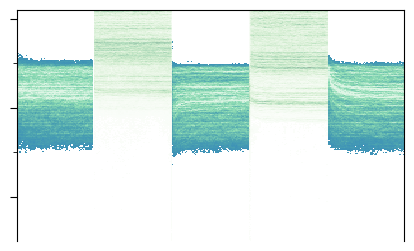

In [ ]:
fig, ax = plt.subplots(figsize=(5,3))
import matplotlib.colors as mcolors
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    "blue_red", ["#3486bc","#4ba2b0d9","#8ad9b2da","#def5e5"]
)
intervals = [(0,98), (99,200), (200,299), (299,401), (402,500)]
for i, (start, end) in enumerate(intervals):
    mask = (datahhh['x'] >= start) & (datahhh['x'] < end)
    x_seg = datahhh.loc[mask, 'x']
    y_seg = datahhh.loc[mask, 'log']
    xrange = (start,end)
    yrange = (-6, -2.9)
    # 控制颜色映射和透明度
    if (start, end) in [(99,200), (299,401)]:
        # 淡一些
        h = ax.hist2d(x_seg, y_seg, vmin=0,cmin=5
                      ,

                      bins=[60,800], cmap="Greens",range=[xrange,yrange], alpha=0.4)
    else:
        # 正常显示
        h = ax.hist2d(x_seg, y_seg, vmin=0, cmin=60,vmax=450,
                      bins=[60,600], cmap=cmap_custom, range=[xrange,yrange],alpha=1.0)

# 公共设置
ax.set_ylim(-5.5, -2.9)
ax.set_xlim(0,500)
# ax.set_xlabel("Time (ms)",fontdict={'fontsize': 13, 'fontweight': 'bold'},labelpad=4)
# ax.set_ylabel(r"Log (G/G$\regular{_0}$)",fontdict={'fontsize': 13, 'fontweight': 'bold'},labelpad=4)
ax.minorticks_on()
ax.tick_params(axis='both',which='minor',length=3)
ax.tick_params(axis='both',which='major',length=5)
# ax.xaxis.set_minor_locator(MultipleLocator(50))
# ax.yaxis.set_major_locator(MultipleLocator(1))
# ax.yaxis.set_minor_locator(MultipleLocator(0.5))
ax.set_yticks([-5,-4,-3])
ax.set_yticks([-4.5,-3.5], minor=True)
ax.set_xticks([])
ax.set_yticklabels([])
ax.spines['bottom'].set_visible(False)
# plt.xticks([])
# plt.yticks([])
# plt.xticks(fontsize=12,fontweight='bold')
# plt.yticks(fontsize=12,fontweight='bold')

# 统一 colorbar（来自最后一次 hist2d 的结果）
# cax = fig.add_axes([ax.get_position().x0+0.02,ax.get_position().y0+0.02,0.03,ax.get_position().height*0.2])
# colorbar = plt.colorbar(h[3], cax=cax,ticks=[0, 225,450])
# # 修改刻度字体大小
# colorbar.ax.tick_params(labelsize=8)
# for tl in colorbar.ax.get_yticklabels():   # 若是水平 colorbar 用 get_xticklabels()
#     tl.set_fontweight('bold')
# 加粗 colorbar 外框线
# plt.savefig('./hhl1.png',dpi=300)
plt.savefig('./hhh0307_无坐标.png',transparent=True,dpi=300)
plt.show()

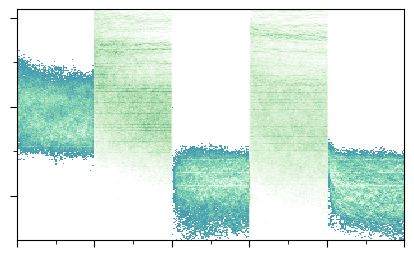

In [ ]:
fig, ax = plt.subplots(figsize=(5,3))
import matplotlib.colors as mcolors
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    "blue_red", ["#3486bc","#4ba2b0d9","#8ad9b2da","#def5e5"]
)
intervals = [(0,99), (99,200), (200,299), (299,402), (402,500)]
for i, (start, end) in enumerate(intervals):
    mask = (datahll['x'] >= start) & (datahll['x'] < end)
    x_seg = datahll.loc[mask, 'x']
    y_seg = datahll.loc[mask, 'log']
    xrange = (start,end)
    yrange = (-6, -2.9)
    # 控制颜色映射和透明度
    if (start, end) in [(99,200), (299,402)]:
        # 淡一些
        h = ax.hist2d(x_seg, y_seg, vmin=0,cmin=10,

                      bins=[60,800], cmap="Greens",range=[xrange,yrange], alpha=0.6)
    else:
        # 正常显示
        h = ax.hist2d(x_seg, y_seg, vmin=0, cmin=28,vmax=120,
                      bins=[60,826], cmap=cmap_custom, range=[xrange,yrange],alpha=1.0)

# 公共设置
ax.set_ylim(-5.5, -2.9)
ax.set_xlim(0,500)
# ax.set_xlabel("Time (ms)",fontdict={'fontsize': 13, 'fontweight': 'bold'},labelpad=4)
# ax.set_ylabel(r"Log (G/G$\regular{_0}$)",fontdict={'fontsize': 13, 'fontweight': 'bold'},labelpad=4)
ax.minorticks_on()
ax.tick_params(axis='both',which='minor',length=3)
ax.tick_params(axis='both',which='major',length=5)
ax.xaxis.set_minor_locator(MultipleLocator(50))
# ax.yaxis.set_major_locator(MultipleLocator(1))
# ax.yaxis.set_minor_locator(MultipleLocator(0.5))
ax.set_yticks([-5,-4,-3])
ax.set_yticks([-4.5,-3.5], minor=True)
ax.set_xticklabels([])
ax.set_yticklabels([])
# ax.set_xticklabels([0,100,])
# ax.set_xticklabels([])
# plt.xticks(fontsize=12,fontweight='bold')
# plt.yticks(fontsize=12,fontweight='bold')

# 统一 colorbar（来自最后一次 hist2d 的结果）
# cax = fig.add_axes([ax.get_position().x0+0.02,ax.get_position().y0+0.02,0.03,ax.get_position().height*0.2])
# colorbar = plt.colorbar(h[3], cax=cax,ticks=[0, 60,120])
# # 修改刻度字体大小
# colorbar.ax.tick_params(labelsize=8)
# for tl in colorbar.ax.get_yticklabels():   # 若是水平 colorbar 用 get_xticklabels()
#     tl.set_fontweight('bold')
plt.savefig('./hll0307_无坐标.png',transparent=True,dpi=300)
plt.show()

In [ ]:
bin_labels = []
hhl_count = []
hlh_count = []
mem_step_count = []
valid_step_count = []
bili = []
step_hhl1 = step_hhl['conduct'].values
step_hlh1 = step_hlh['conduct'].values
valid_step1 = valid_step['conduct'].values
if len(step_hhl) > 0:
    # max_step = int(max(step_hhl))
    for i in range(len(labelbin)):
        if i==len(labelbin)-1:
            # mem_count = ((mem_perfe_step >= labelbin[i])).sum()
            hhl_step_count = ((step_hhl1 >= labelbin[i])& (step_hhl1 < 909.09)).sum()
            hlh_step_count =((step_hlh1 >= labelbin[i])& (step_hlh1 < 909.09)).sum()
            mem_count = hhl_step_count + hlh_step_count
            valid_count = ((valid_step1 >= labelbin[i])& (valid_step1 < 909.09)).sum()
            print(f"{i}:{labelbin[i]}")
        else:
            hhl_step_count = ((step_hhl1 >= labelbin[i]) & (step_hhl1 < labelbin[i+1] )).sum()
            hlh_step_count = ((step_hlh1 >= labelbin[i]) & (step_hlh1 < labelbin[i+1])).sum()
            mem_count = hhl_step_count + hlh_step_count
            valid_count = ((valid_step1 >= labelbin[i]) & (valid_step1 < labelbin[i+1])).sum().sum()
        if valid_count > 0:
            current = mem_count*1.0 / (valid_count)*1.0
        else:
            current = 0
            
        bili.append(current)
        hlh_count.append(hlh_step_count)
        hhl_count.append(hhl_step_count)
        mem_step_count.append(mem_count)
        valid_step_count.append(valid_count)
        bin_labels.append(f'{(i*0.5+0.5):.1f}-{(i+1)*0.5+0.5:.1f}')

In [ ]:
import numpy as np
import pandas as pd

def bootstrap_bin_proportion_ci(success_counts, total_counts, bin_labels,
                                n_boot=10000, ci=95, random_state=42):
    """
    success_counts: 每个 bin 中 memristive step 数量，例如 mem_step_count
    total_counts: 每个 bin 中 valid step 总数，例如 valid_step_count
    bin_labels: 每个 bin 的标签
    """

    rng = np.random.default_rng(random_state)
    alpha = (100 - ci) / 2

    rows = []

    for label, k, n in zip(bin_labels, success_counts, total_counts):
        print(label,k,n)
        k = int(k)
        n = int(n)

        if n == 0:
            rows.append({
                "bin": label,
                "N_valid": n,
                "N_mem": k,
                "p_hat": np.nan,
                f"ci{ci}_low": np.nan,
                f"ci{ci}_high": np.nan,
            })
            continue

        # 非参数 bootstrap：在该 bin 内构造 0/1 标签并有放回抽样
        labels = np.r_[np.ones(k, dtype=int), np.zeros(n - k, dtype=int)]

        boot_props = np.empty(n_boot)
        for b in range(n_boot):
            sample = rng.choice(labels, size=n, replace=True)
            boot_props[b] = sample.mean()

        p_hat = k / n
        ci_low, ci_high = np.percentile(boot_props, [alpha, 100 - alpha])

        rows.append({
            "bin": label,
            "N_valid": n,
            "N_mem": k,
            "p_hat": p_hat,
            f"ci{ci}_low": ci_low,
            f"ci{ci}_high": ci_high,
        })

    return pd.DataFrame(rows)


boot_df = bootstrap_bin_proportion_ci(
    success_counts=mem_step_count,
    total_counts=valid_step_count,
    bin_labels=bin_labels,
    n_boot=100000,
    ci=95,
)

boot_df

0.5-1.0 99 620
1.0-1.5 95 864
1.5-2.0 21 170
2.0-2.5 1 45


,bin,N_valid,N_mem,p_hat,ci95_low,ci95_high
0,0.5-1.0,620,99,0.159677,0.132258,0.188710
1,1.0-1.5,864,95,0.109954,0.089120,0.130787
2,1.5-2.0,170,21,0.123529,0.076471,0.176471
3,2.0-2.5,45,1,0.022222,0.000000,0.066667


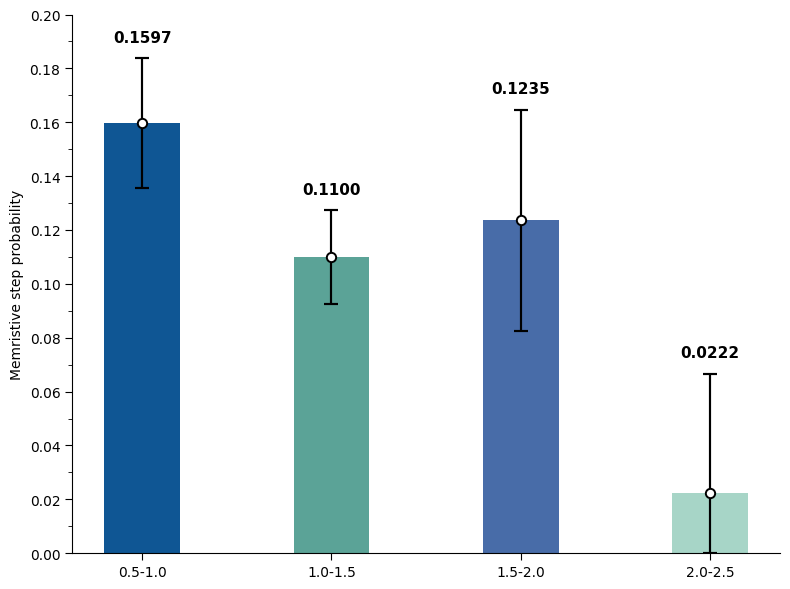

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator

# 建议直接使用 bootstrap 结果，避免手动输入概率出错
labels = boot_df["bin"].tolist()
probs = boot_df["p_hat"].to_numpy(dtype=float)
ci_low = boot_df["ci90_low"].to_numpy(dtype=float)
ci_high = boot_df["ci90_high"].to_numpy(dtype=float)

n = len(labels)
x = np.arange(n)

colors = ["#0F5694FF", "#5ba397ff", "#486CA8", "#A7D5C7"]
bar_width = 0.4

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    x,
    probs,
    color=colors[:n],
    width=bar_width,
    zorder=2
)

# bootstrap 置信区间是不对称误差棒
yerr_lower = probs - ci_low
yerr_upper = ci_high - probs

ax.errorbar(
    x,
    probs,
    yerr=[yerr_lower, yerr_upper],
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=5,
    capthick=1.5,
    zorder=3
)
ax.errorbar(
    x,
    probs,
    yerr=[yerr_lower, yerr_upper],
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=5,
    capthick=1.5,
    zorder=3
)

ax.scatter(
    x,
    probs,
    s=45,
    facecolors="white",
    edgecolors="black",
    linewidths=1.4,
    zorder=4
)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, rotation=0, ha="center")

# 标注柱子高度
for i, v in enumerate(probs):
    ax.text(
        i,
        ci_high[i] + 0.006,
        f"{v:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# 注意：你的最高 CI 到 0.1887，所以 ylim 不能设 0.16
ax.set_ylim(0, 0.2)

ax.tick_params(axis="both", which="minor", length=3)
ax.tick_params(axis="both", which="major", length=5)

ax.yaxis.set_major_locator(MultipleLocator(0.02))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))

# 如果你前面定义了 minor_positions，可以保留
# ax.xaxis.set_minor_locator(FixedLocator(minor_positions))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylabel("Memristive step probability")

plt.tight_layout()
plt.savefig("proba_bar_horiz0608_bootstrap.png", transparent=True, dpi=300)
plt.show()